In [90]:
import os
import numpy as np
from glob import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,   Dataset
import  matplotlib.pyplot as plt
import cv2
import torchvision.transforms as T
from scipy.io import loadmat
from torchvision import transforms
from PIL import Image


# Model Build

In [91]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, num_classes=1):
        super(UNet, self).__init__()
        
        # def Crowd(in_channels, out_channels):
        #     return nn.Sequential(
        #         nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        #         nn.BatchNorm2d(out_channels),
        #         nn.ReLU(inplace=True),
        #         nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        #         nn.BatchNorm2d(out_channels),
        #         nn.ReLU(inplace=True),
        #     )
        def Crowd(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Dropout2d(0.3)  
            )
        
        self.enc1 = Crowd(3, 64)
        self.enc2 = Crowd(64, 128)
        self.enc3 = Crowd(128, 256)
        self.enc4 = Crowd(256, 512)
        self.enc5 = Crowd(512, 1024)

        self.pool = nn.MaxPool2d(2)  
        
        self.bottleneck = Crowd(1024, 2048)

        self.upconv5 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.dec5 = Crowd(2048, 1024)
        
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = Crowd(1024, 512)
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = Crowd(512, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = Crowd(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = Crowd(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e5 = self.enc5(self.pool(e4))

        b = self.bottleneck(self.pool(e5))

        d5 = self.upconv5(b)
        d5 = self.dec5(torch.cat([d5, e5], dim=1))
        
        d4 = self.upconv4(d5)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        
        d3 = self.upconv3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = self.upconv2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = self.upconv1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.final(d1))



In [92]:
device = "cuda"
model = UNet(num_classes=1)  
model = model.to(device)

# Before its completed

# Dataset part

In [93]:
mat = loadmat("ShanghaiTech/part_B_final/train_data/ground_truth/GT_IMG_10.mat")
print(mat.keys())
print(mat['image_info'])

dict_keys(['__header__', '__version__', '__globals__', 'image_info'])
[[array([[(array([[ 1.30650369e+02,  3.53611408e+02],
                 [ 8.46855106e+00,  2.43897122e+02],
                 [ 1.24166030e+01,  1.94338681e+02],
                 [ 6.18283677e+00,  1.41351668e+02],
                 [ 9.29971989e+00,  1.28884135e+02],
                 [ 2.92477718e+01,  1.22026993e+02],
                 [ 8.03646550e+01,  1.08936084e+02],
                 [ 1.04052967e+02,  9.14815381e+01],
                 [ 1.17767252e+02,  8.96114082e+01],
                 [ 1.35221798e+02,  1.45715304e+02],
                 [ 1.30858161e+02,  1.67533486e+02],
                 [ 1.27117902e+02,  1.95585434e+02],
                 [ 5.85464731e+01,  1.76884135e+02],
                 [ 1.65767252e+02,  1.36988032e+02],
                 [ 1.44572447e+02,  5.40789407e+01],
                 [ 1.19637382e+02,  3.66243952e+01],
                 [ 9.34555640e+01,  1.23127069e+01],
                 [ 9.4078940

# Dataloader

In [94]:
class ShanghaiTechCrowdCountingDataset(Dataset):
    def __init__(self, image_dir, gt_dir, transform=None, img_size=(256, 256)):
        self.image_dir = image_dir
        self.gt_dir = gt_dir
        self.transform = transform
        self.img_size = img_size
        self.image_files = sorted(os.listdir(image_dir))  
        self.gt_files = sorted(os.listdir(gt_dir))  

    def __len__(self):
        return len(self.image_files)

    def generate_density_map(self, img, coordinates):
        density_map = np.zeros(img.shape[:2], dtype=np.float32)

        kernel_size = 15  
        sigma = 4.0  

        for coord in coordinates:
            x, y = int(coord[0]), int(coord[1])
            
            gaussian_kernel = self.create_gaussian_kernel(kernel_size, sigma)
            
            x_min = max(x - kernel_size // 2, 0)
            y_min = max(y - kernel_size // 2, 0)
            x_max = min(x + kernel_size // 2, img.shape[1])
            y_max = min(y + kernel_size // 2, img.shape[0])

            if x_max > x_min and y_max > y_min:
                density_map[y_min:y_max, x_min:x_max] += gaussian_kernel[:y_max - y_min, :x_max - x_min]

        density_map = np.clip(density_map, 0, 255)
        return density_map


    def create_gaussian_kernel(self, kernel_size, sigma):
        ax = np.linspace(-(kernel_size // 2), kernel_size // 2, kernel_size)
        xx, yy = np.meshgrid(ax, ax)
        kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
        kernel /= np.sum(kernel)  
        return kernel

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        gt_path = os.path.join(self.gt_dir, self.gt_files[idx])
        
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  
        
        mat_data = loadmat(gt_path)
        coordinates = mat_data['image_info'][0, 0]['location'][0, 0]  

        density_map = self.generate_density_map(image, coordinates)
        
        image = cv2.resize(image, self.img_size)
        density_map = cv2.resize(density_map, self.img_size)

        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)
        
        density_map = torch.tensor(density_map, dtype=torch.float32).unsqueeze(0)  

        return image, density_map

# Dataset Load

In [ ]:
image_dir = "ShanghaiTech/part_B_final/train_data/images"
gt_dir = "ShanghaiTech/part_B_final/train_data/ground_truth"

# transform = transforms.Compose([
#     transforms.Resize((256, 256)),  
#     transforms.ToTensor(),  
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
# ])
# transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(30),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])


train_dataset = ShanghaiTechCrowdCountingDataset(image_dir=image_dir, gt_dir=gt_dir, transform=transform)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

for images, density_maps in train_loader:
    print("Batch of images shape:", images.shape)  
    print("Batch of density maps shape:", density_maps.shape)  
    break  


Batch of images shape: torch.Size([4, 3, 256, 256])
Batch of density maps shape: torch.Size([4, 1, 256, 256])


In [96]:
image_dir = "ShanghaiTech/part_B_final/test_data/images"
gt_dir = "ShanghaiTech/part_B_final/test_data/ground_truth"
val_dataset = ShanghaiTechCrowdCountingDataset(image_dir=image_dir, gt_dir=gt_dir, transform=transform)

batch_size = 4
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

for images, density_maps in val_loader:
    print("Batch of images shape:", images.shape)  
    print("Batch of density maps shape:", density_maps.shape)  
    break  


Batch of images shape: torch.Size([4, 3, 256, 256])
Batch of density maps shape: torch.Size([4, 1, 256, 256])


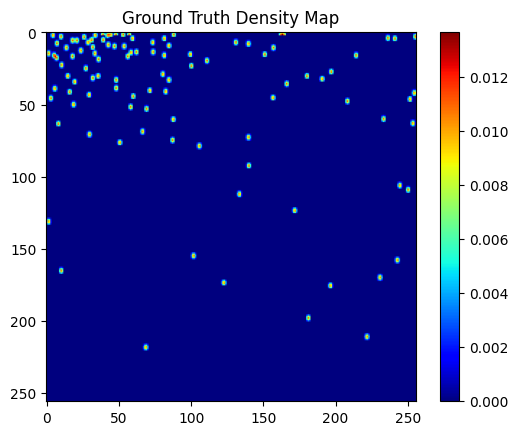

In [97]:
sample_img, sample_gt_map = next(iter(val_loader))  
sample_gt_map = sample_gt_map[3].cpu().numpy().squeeze()

plt.imshow(sample_gt_map, cmap='jet')
plt.title(f"Ground Truth Density Map")
plt.colorbar()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


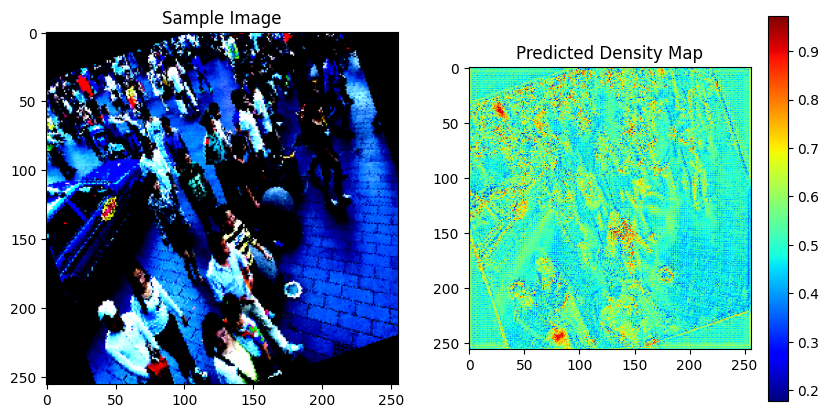

In [100]:
import matplotlib.pyplot as plt

def plot_density_map(pred_density_map, sample_img, sample_gt_map):
    plt.figure(figsize=(10, 5))

    # Display the sample image
    plt.subplot(1, 2, 1)
    plt.imshow(sample_img.permute(1, 2, 0).cpu().numpy())  # Image is CxHxW, need to permute to HxWxC
    plt.title("Sample Image")
    
    # Ensure that the predicted density map has the correct shape
    if pred_density_map.ndim == 3:  # If it has the shape (1, H, W), squeeze the first dimension
        pred_density_map = pred_density_map.squeeze(0)  # (H, W)
    elif pred_density_map.ndim == 4:  # If it has the shape (batch_size, 1, H, W), we can select the first item
        pred_density_map = pred_density_map[0, 0, :, :]  # Select the first sample and remove the channel dimension

    # Plot the predicted density map
    plt.subplot(1, 2, 2)
    plt.imshow(pred_density_map, cmap='jet')  # Show the predicted density map with jet colormap
    plt.colorbar()
    plt.title("Predicted Density Map")
    
    plt.show()


# Visualize during validation
sample_img, sample_gt_map = next(iter(val_loader))
sample_img, sample_gt_map = sample_img.to(device), sample_gt_map.to(device)

# Get prediction
pred_density_map = model(sample_img).cpu().detach().numpy()
pred_density_map = np.maximum(pred_density_map, 0)
pred_density_map = np.clip(pred_density_map, 0, 1)

# Plot
plot_density_map(pred_density_map, sample_img[0], sample_gt_map[0])


In [113]:
criterion = nn.BCEWithLogitsLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

In [102]:
def count_people(density_map):
    count = np.sum(density_map>0)
    print(f"Counted {count} people in the density map.")
    return count

In [103]:
def evaluate_model(model, val_loader, device):
    model.eval()  
    running_loss = 0.0
    with torch.no_grad():  
        for imgs, gt_maps in val_loader:
            imgs, gt_maps = imgs.to(device), gt_maps.to(device)
            
            outputs = model(imgs)
            outputs = torch.sigmoid(outputs)
            outputs = torch.clamp(outputs, min=0, max=1)  

            
            loss = criterion(outputs, gt_maps)
            running_loss += loss.item()
    
    avg_loss = running_loss / len(val_loader)
    return avg_loss

In [104]:
def plot(gt_count, pred_density_map, pred_count, image, sam_gt_map):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image.cpu().numpy().transpose(1, 2, 0))
    plt.title("Input Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sam_gt_map.cpu().numpy().squeeze(), cmap='jet')
    plt.title(f"Ground Truth: {gt_count} People")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_density_map.squeeze(), cmap='jet')
    plt.title(f"Predicted: {pred_count} People")
    plt.axis('off')

    plt.show()

Epoch 1/20, Train Loss: 0.34496897310018537, Validation Loss: 0.3234257200096227


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Counted 2541 people in the density map.
Counted 65536 people in the density map.


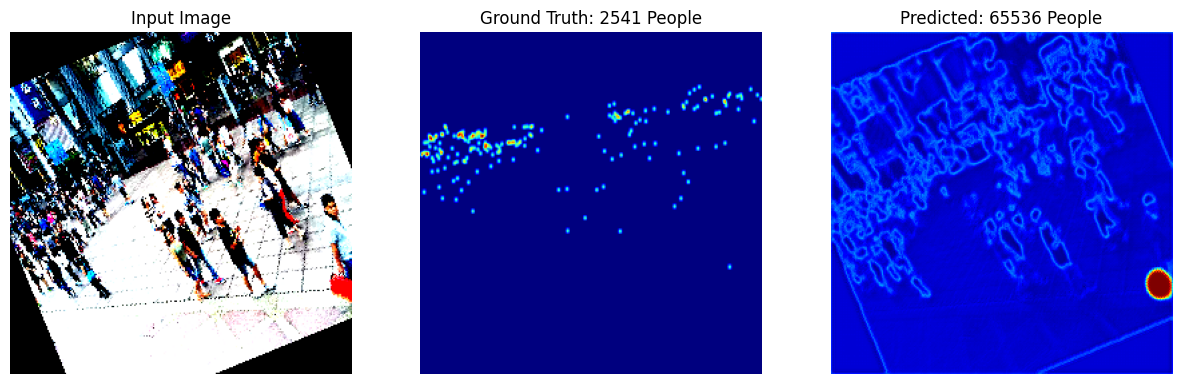

Epoch 2/20, Train Loss: 0.31707792103290555, Validation Loss: 0.3124852716168271


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Counted 2105 people in the density map.
Counted 65536 people in the density map.


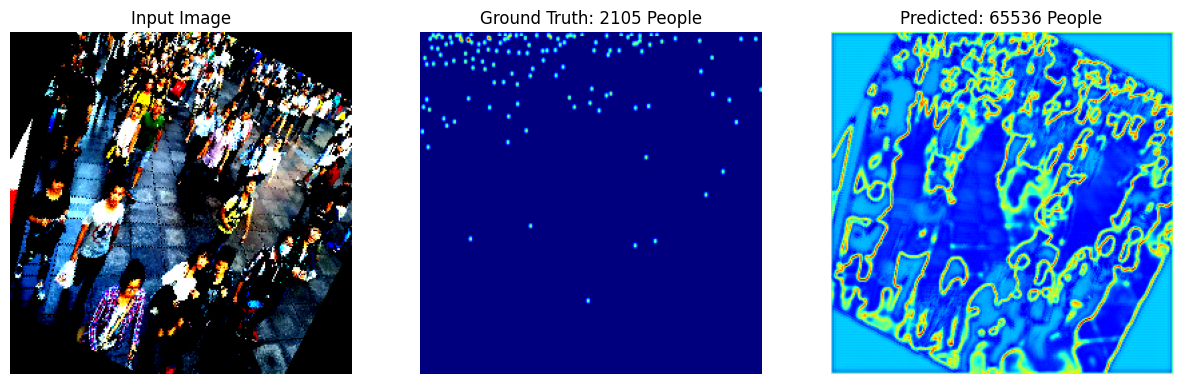

KeyboardInterrupt: 

In [106]:
num_epochs = 20
for epoch in range(num_epochs):
    model.train()  
    running_loss = 0.0
    for imgs, gt_maps in train_loader:
        imgs, gt_maps = imgs.to(device), gt_maps.to(device)

        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(imgs)
        outputs = torch.sigmoid(outputs)  
        outputs = torch.clamp(outputs, min=0, max=1)
        
        # Compute loss
        loss = criterion(outputs, gt_maps)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation Loss
    val_loss = evaluate_model(model, val_loader, device)
    
    # Print progress
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {running_loss/len(train_loader)}, Validation Loss: {val_loss}")
    
    # Evaluation every epoch
    if (epoch + 1) % 1 == 0:  
        model.eval()
        with torch.no_grad():
            sample_img, sample_gt_map = next(iter(val_loader))
            sample_img, sample_gt_map = sample_img.to(device), sample_gt_map.to(device)

            # Model prediction
            pred_density_map = model(sample_img).cpu().numpy()
            pred_density_map = np.maximum(pred_density_map, 0)  # Ensure no negative values
            pred_density_map = np.clip(pred_density_map, 0, 1)  # Ensure values are between [0, 1]

            # Directly count people using sum of density map
            gt_count = count_people(sample_gt_map.cpu().numpy()[0])
            pred_count = count_people(pred_density_map[0])
            
            # Plot the results
            plot(gt_count, pred_density_map[0], pred_count, sample_img[0], sample_gt_map[0])

In [ ]:
import scipy.io

mat_data = scipy.io.loadmat("ShanghaiTech/part_B_final/train_data/ground_truth/GT_IMG_1.mat")
image_info = mat_data['image_info']
locations = image_info[0, 0]['location'][0]
print(locations)  # Inspect the raw locations for a specific image


[array([[ 3.26795488e+01,  7.53521654e+02],
        [ 1.84606953e+02,  6.90799331e+02],
        [ 3.44897335e+02,  5.77899149e+02],
        [ 3.28171382e+02,  5.36084267e+02],
        [ 3.29565211e+02,  4.73361944e+02],
        [ 6.43176826e+02,  5.33296609e+02],
        [ 6.61296609e+02,  6.81042525e+02],
        [ 8.03467208e+02,  5.80686808e+02],
        [ 8.14617843e+02,  5.02632362e+02],
        [ 7.57470837e+02,  3.92519839e+02],
        [ 7.70015302e+02,  3.64643251e+02],
        [ 7.99285719e+02,  3.15859222e+02],
        [ 7.28200420e+02,  3.28403687e+02],
        [ 8.99641436e+02,  4.05064304e+02],
        [ 9.19155048e+02,  5.29115120e+02],
        [ 9.24730365e+02,  2.78225828e+02],
        [ 9.65151418e+02,  2.50349240e+02],
        [ 1.01811694e+03,  2.36410946e+02],
        [ 9.38668659e+02,  1.86233088e+02],
        [ 8.96853777e+02,  1.68113306e+02],
        [ 8.78733995e+02,  1.83445429e+02],
        [ 9.58182271e+02,  1.30479912e+02],
        [ 9.51213124e+02,  8.308

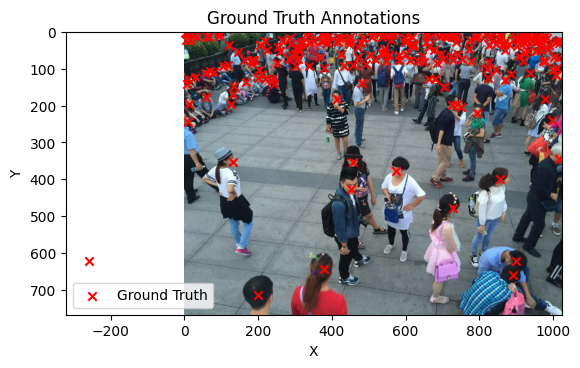

In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load the ground truth data
mat_data = scipy.io.loadmat("ShanghaiTech/part_B_final/train_data/ground_truth/GT_IMG_10.mat")

# Extract the coordinates (x, y) of the people in the image
coordinates = mat_data['image_info'][0, 0]['location'][0, 0]

# Load the corresponding image (replace the path with the actual image path)
image = cv2.imread("ShanghaiTech/part_B_final/train_data/images/IMG_10.jpg")  # Change path if needed

# Convert the BGR image to RGB (since OpenCV loads images in BGR format)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plot the image with the coordinates overlaid
plt.imshow(image_rgb)
plt.scatter(coordinates[:, 0], coordinates[:, 1], c='red', marker='x', label='Ground Truth')
plt.title("Ground Truth Annotations")
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()


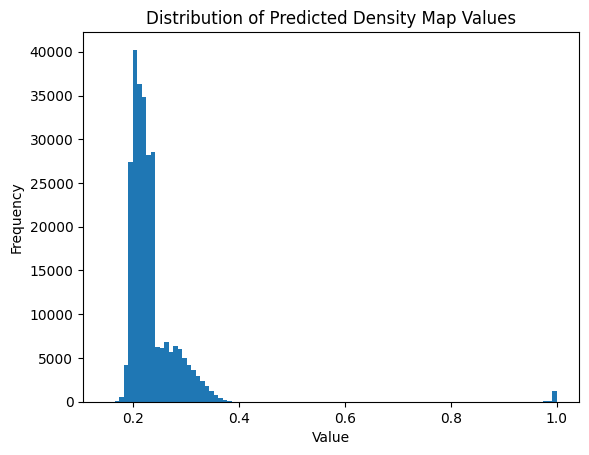

In [108]:
plt.hist(pred_density_map.flatten(), bins=100)
plt.title("Distribution of Predicted Density Map Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [111]:
early_stopping_patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, gt_maps in train_loader:
        imgs, gt_maps = imgs.to(device), gt_maps.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        outputs = torch.sigmoid(outputs)  
        
        loss = criterion(outputs, gt_maps)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    # Validation Loss
    val_loss = evaluate_model(model, val_loader, device)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {running_loss/len(train_loader)}, Validation Loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping after {epoch+1} epochs due to no improvement.")
        break


Epoch 1/20, Train Loss: 0.30284425109624863, Validation Loss: 0.2996346942986114
Epoch 2/20, Train Loss: 0.29512865871191024, Validation Loss: 0.291651790655112
Epoch 3/20, Train Loss: 0.2906734871864319, Validation Loss: 0.2865934051290343


KeyboardInterrupt: 

Epoch 1/20, Train Loss: 0.9833131229877472, Validation Loss: 0.9815428166449824


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


(4, 1, 256, 256)
Counted 4692 people in the density map.
Counted 0 people in the density map.


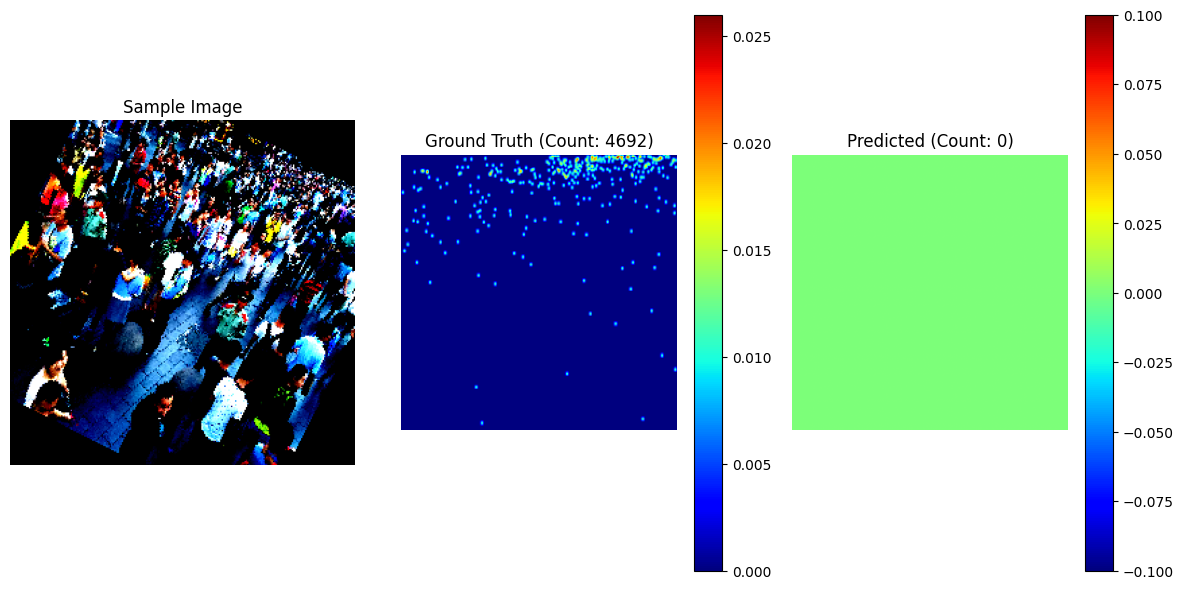

KeyboardInterrupt: 

In [119]:
import matplotlib.pyplot as plt

early_stopping_patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, gt_maps in train_loader:
        imgs, gt_maps = imgs.to(device), gt_maps.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(imgs)
        outputs = torch.sigmoid(outputs)  # Sigmoid if using BCEWithLogitsLoss
        
        # Compute loss
        loss = criterion(outputs, gt_maps)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    # Validation Loss
    val_loss = evaluate_model(model, val_loader, device)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {running_loss/len(train_loader)}, Validation Loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Early stopping condition
    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping after {epoch+1} epochs due to no improvement.")
        break
    
    # Plot a sample of predicted and ground truth density maps
    model.eval()
    with torch.no_grad():
        sample_img, sample_gt_map = next(iter(val_loader))
        sample_img, sample_gt_map = sample_img.to(device), sample_gt_map.to(device)

        pred_density_map = model(sample_img).cpu().numpy()
        pred_density_map = np.maximum(pred_density_map, 0)
        pred_density_map = np.clip(pred_density_map, 0, 1)
        
        print(pred_density_map.shape)

        pred_density_map = pred_density_map[0, 0] 

        threshold = 0.3
        pred_density_map[pred_density_map < threshold] = 0

        # Count the number of people in both ground truth and predicted density maps
        gt_count = count_people(sample_gt_map.cpu().numpy()[0])  # Ground truth count
        pred_count = count_people(pred_density_map[0])  # Predicted count
        
        # Plot the sample image, ground truth density map, and predicted density map
        plt.figure(figsize=(12, 6))
        
        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(sample_img[0].cpu().numpy().transpose(1, 2, 0))  # Convert to HxWxC for imshow
        plt.title("Sample Image")
        plt.axis('off')

        # Ground Truth Density Map
        plt.subplot(1, 3, 2)
        plt.imshow(sample_gt_map[0].cpu().numpy().squeeze(), cmap='jet')  # Squeeze to remove singleton dimension
        plt.title(f"Ground Truth (Count: {gt_count})")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(pred_density_map, cmap='jet')
        plt.title(f"Predicted (Count: {pred_count})")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()


Epoch 1/20, Train Loss: 0.9813837921619415, Validation Loss: 0.979705161686185


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


(4, 1, 256, 256)
Counted 2031 people in the density map.
Counted 58 people in the density map.


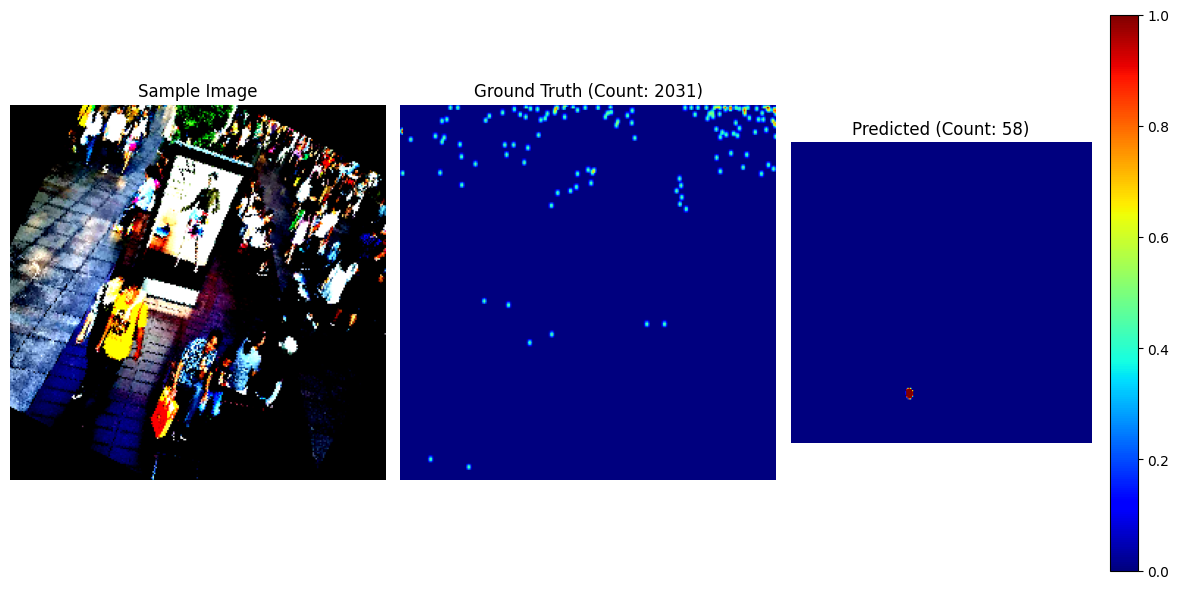

Epoch 2/20, Train Loss: 0.9801042282581329, Validation Loss: 0.9793014503732512


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


(4, 1, 256, 256)
Counted 995 people in the density map.
Counted 842 people in the density map.


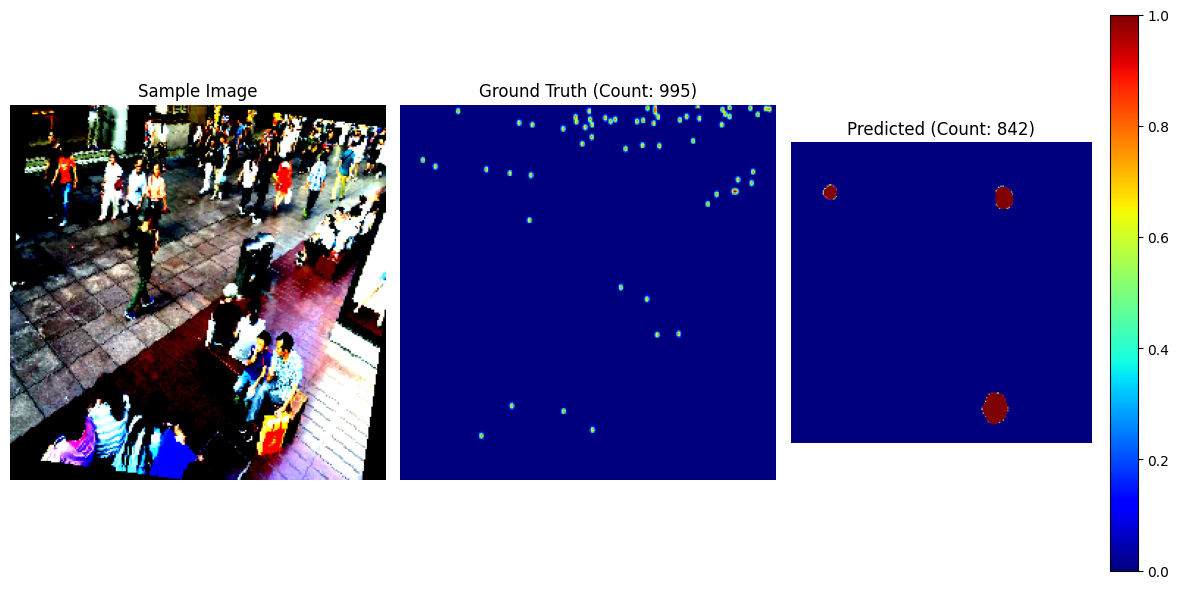

Epoch 3/20, Train Loss: 0.979039551615715, Validation Loss: 0.9779780763614027


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


(4, 1, 256, 256)
Counted 764 people in the density map.
Counted 0 people in the density map.


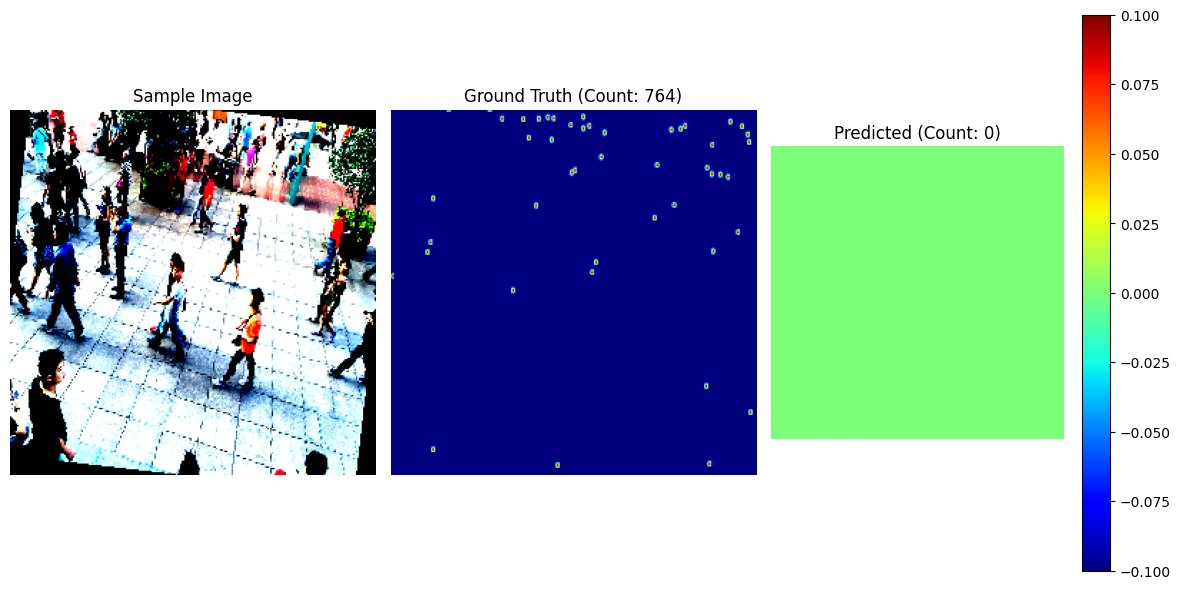

Epoch 4/20, Train Loss: 0.9784159564971924, Validation Loss: 0.9774585743493671


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


(4, 1, 256, 256)
Counted 1809 people in the density map.
Counted 0 people in the density map.


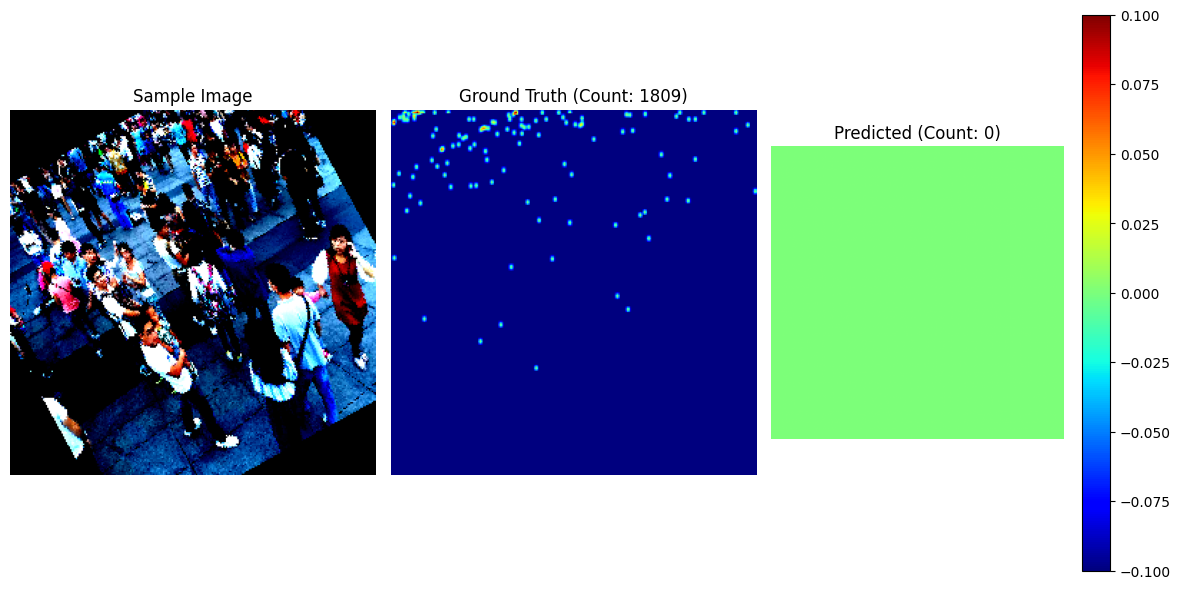

Epoch 5/20, Train Loss: 0.9776529330015182, Validation Loss: 0.9768959940234317


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


(4, 1, 256, 256)
Counted 2110 people in the density map.
Counted 0 people in the density map.


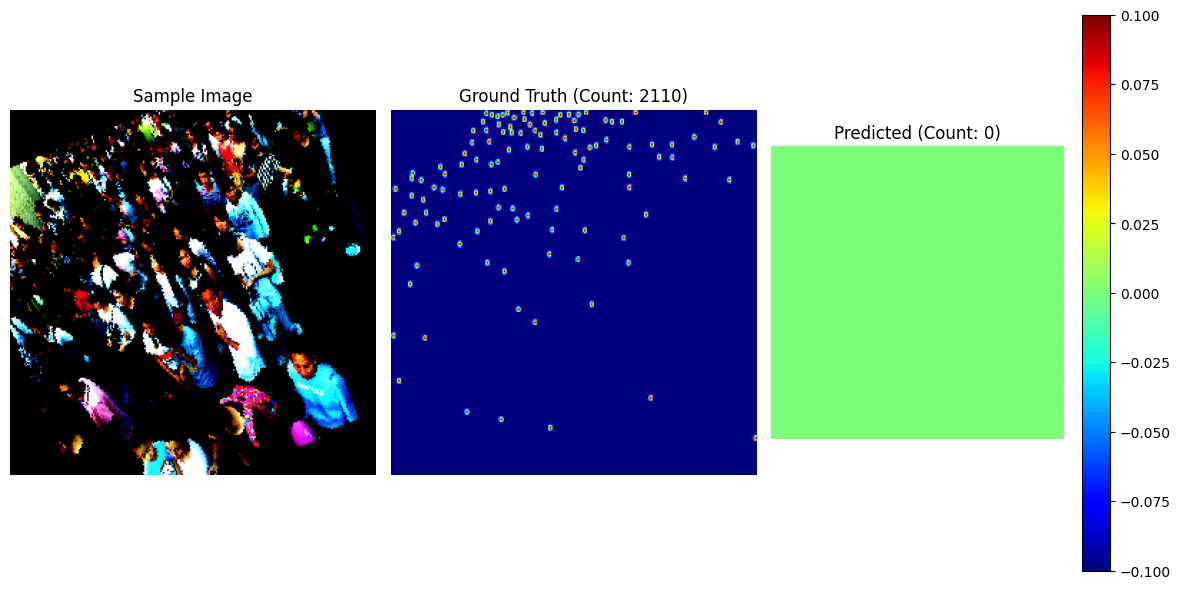

KeyboardInterrupt: 

In [120]:
import matplotlib.pyplot as plt

early_stopping_patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, gt_maps in train_loader:
        imgs, gt_maps = imgs.to(device), gt_maps.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(imgs)
        outputs = torch.sigmoid(outputs)  # Sigmoid if using BCEWithLogitsLoss
        
        # Compute loss
        loss = criterion(outputs, gt_maps)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    # Validation Loss
    val_loss = evaluate_model(model, val_loader, device)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {running_loss/len(train_loader)}, Validation Loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Early stopping condition
    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping after {epoch+1} epochs due to no improvement.")
        break
    
    # Plot a sample of predicted and ground truth density maps
    model.eval()
    with torch.no_grad():
        sample_img, sample_gt_map = next(iter(val_loader))
        sample_img, sample_gt_map = sample_img.to(device), sample_gt_map.to(device)

        # Forward pass
        pred_density_map = model(sample_img).cpu().numpy()
        pred_density_map = np.maximum(pred_density_map, 0)
        pred_density_map = np.clip(pred_density_map, 0, 1)

        print(pred_density_map.shape)  # Debugging: Check shape

        pred_density_map = pred_density_map[0, 0]  # Access the first image

        # Lower threshold to 0.1
        threshold = 0.1
        pred_density_map[pred_density_map < threshold] = 0

        # Count the number of people in both ground truth and predicted density maps
        gt_count = count_people(sample_gt_map.cpu().numpy()[0])  # Ground truth count
        pred_count = count_people(pred_density_map)  # Predicted count

        # Plot the sample image, ground truth density map, and predicted density map
        plt.figure(figsize=(12, 6))
        
        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(sample_img[0].cpu().numpy().transpose(1, 2, 0))  # Convert to HxWxC for imshow
        plt.title("Sample Image")
        plt.axis('off')

        # Ground Truth Density Map
        plt.subplot(1, 3, 2)
        plt.imshow(sample_gt_map[0].cpu().numpy().squeeze(), cmap='jet')  # Squeeze to remove singleton dimension
        plt.title(f"Ground Truth (Count: {gt_count})")
        plt.axis('off')

        # Predicted Density Map (Before thresholding)
        plt.subplot(1, 3, 3)
        plt.imshow(pred_density_map, cmap='jet')
        plt.colorbar()
        plt.title(f"Predicted (Count: {pred_count})")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()


Epoch 1/20, Train Loss: 0.9771056920289993, Validation Loss: 0.9762543998187101


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Predicted Density Map Shape: (4, 1, 256, 256)
Raw prediction values range:  0.004411803 0.023331525
Counted 1201 people in the density map.
Counted 0 people in the density map.


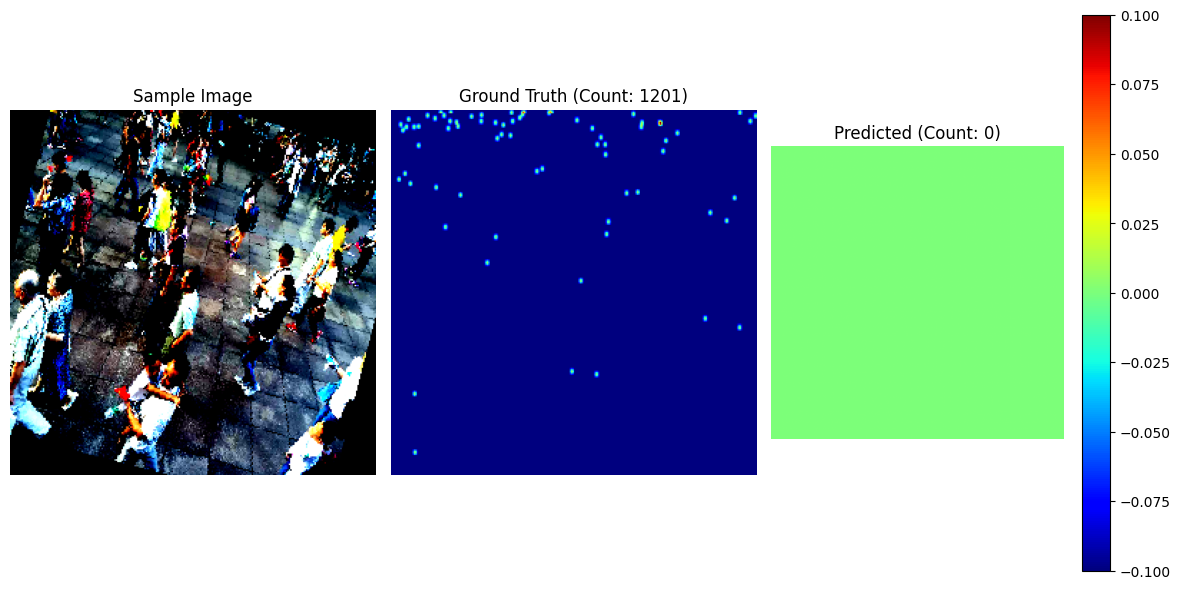

Epoch 2/20, Train Loss: 0.9765154331922531, Validation Loss: 0.9759979685650596


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Predicted Density Map Shape: (4, 1, 256, 256)
Raw prediction values range:  5.5697383e-06 1.0
Counted 2742 people in the density map.
Counted 132 people in the density map.


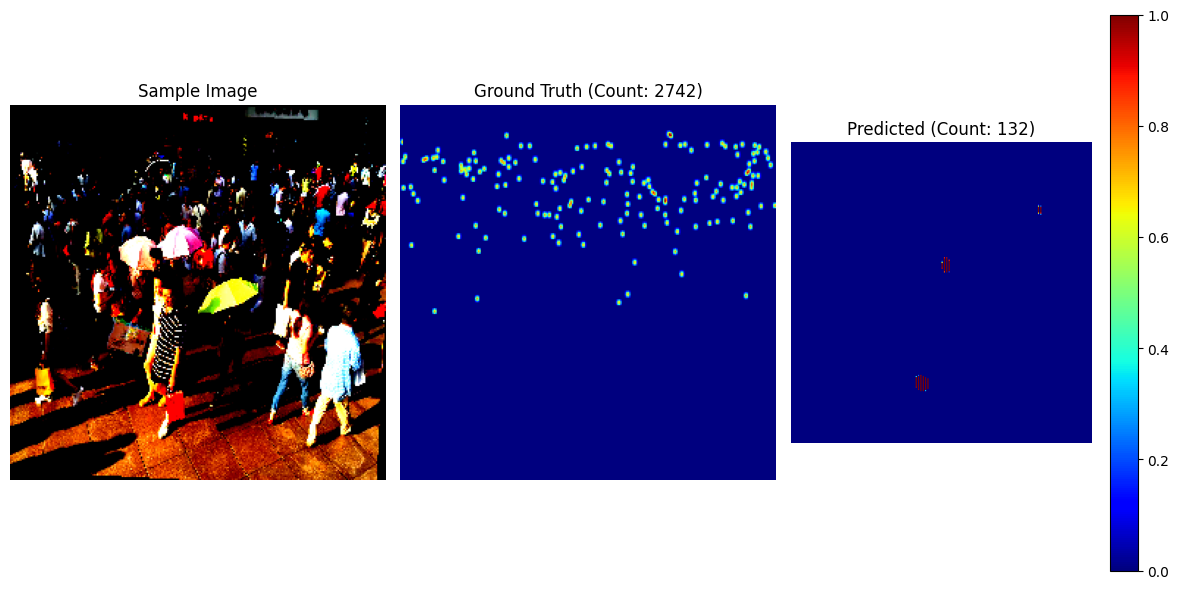

Epoch 3/20, Train Loss: 0.9762896400690079, Validation Loss: 0.9756728810600087


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Predicted Density Map Shape: (4, 1, 256, 256)
Raw prediction values range:  0.0020227847 0.01818811
Counted 335 people in the density map.
Counted 0 people in the density map.


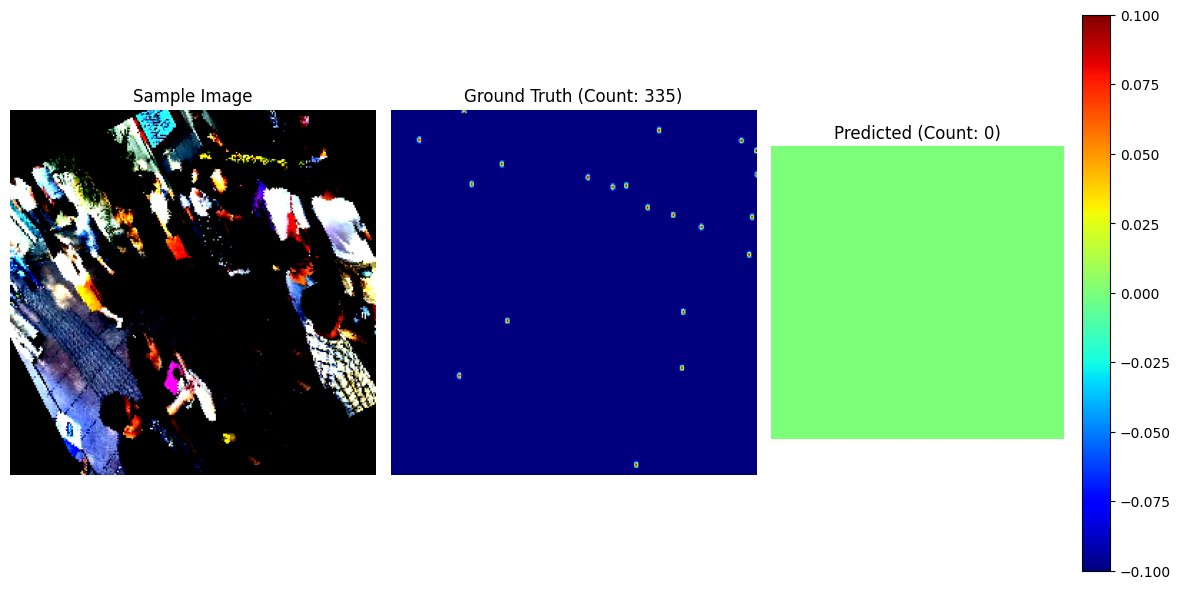

Epoch 4/20, Train Loss: 0.9759933173656463, Validation Loss: 0.9754510280452197


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Predicted Density Map Shape: (4, 1, 256, 256)
Raw prediction values range:  0.0034238165 0.016360413
Counted 699 people in the density map.
Counted 0 people in the density map.


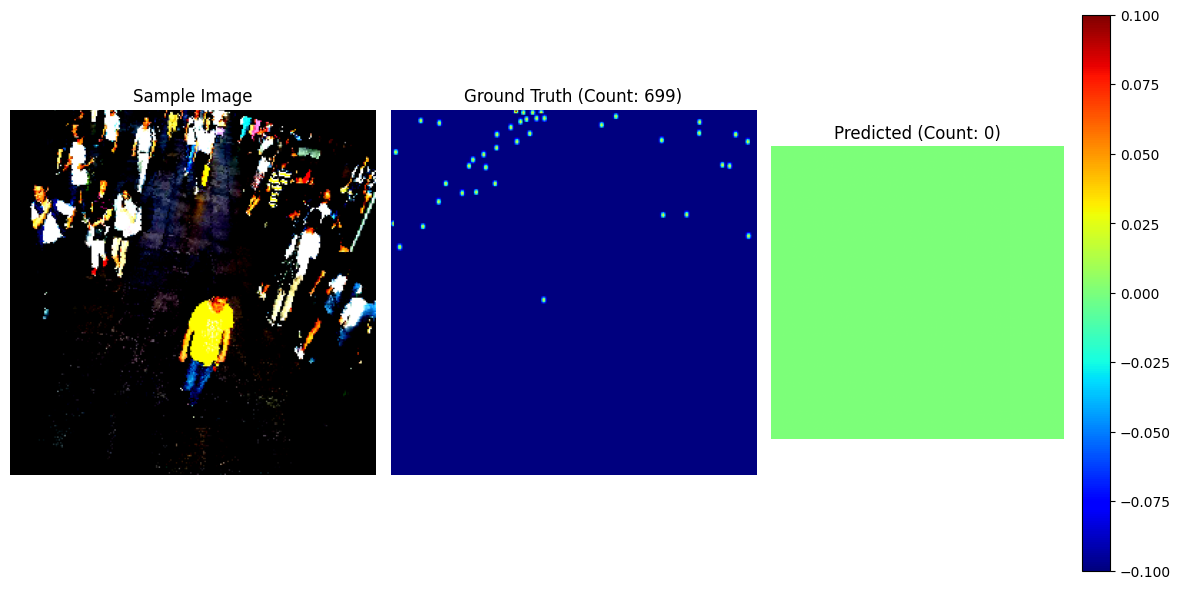

Epoch 5/20, Train Loss: 0.9756682419776916, Validation Loss: 0.9752550939970379


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Predicted Density Map Shape: (4, 1, 256, 256)
Raw prediction values range:  0.001415225 0.01210907
Counted 3602 people in the density map.
Counted 0 people in the density map.


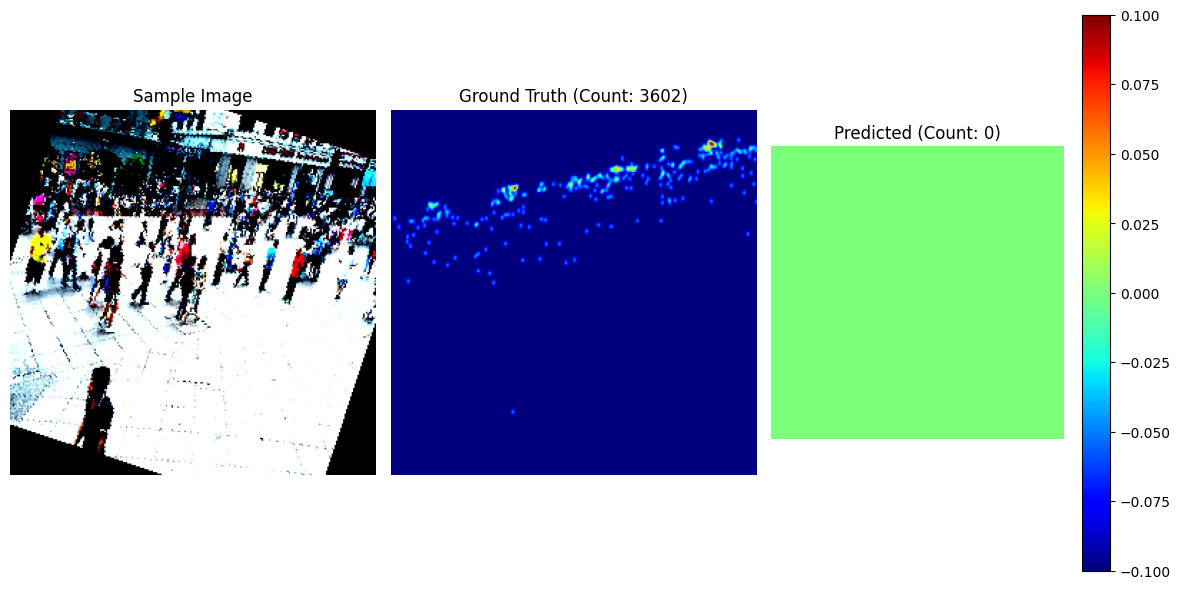

Epoch 6/20, Train Loss: 0.9755083620548248, Validation Loss: 0.9750821809225445


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Predicted Density Map Shape: (4, 1, 256, 256)
Raw prediction values range:  0.0015907692 0.012343975
Counted 921 people in the density map.
Counted 0 people in the density map.


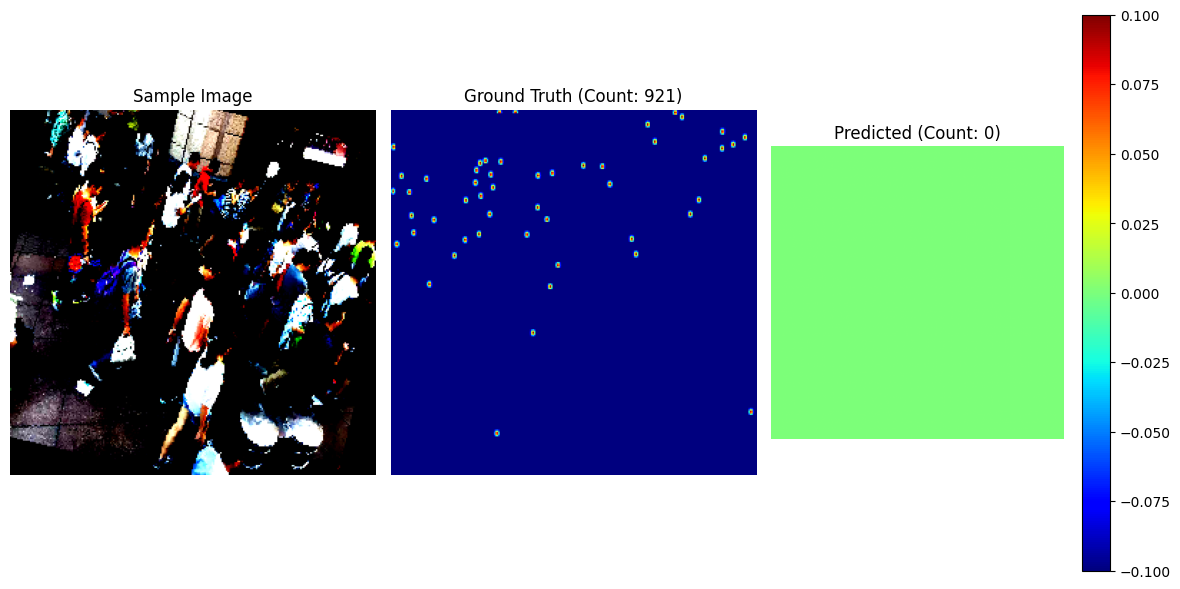

Epoch 7/20, Train Loss: 0.9752669245004654, Validation Loss: 0.9749454342866246


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Predicted Density Map Shape: (4, 1, 256, 256)
Raw prediction values range:  0.00056540663 0.012049408
Counted 3039 people in the density map.
Counted 0 people in the density map.


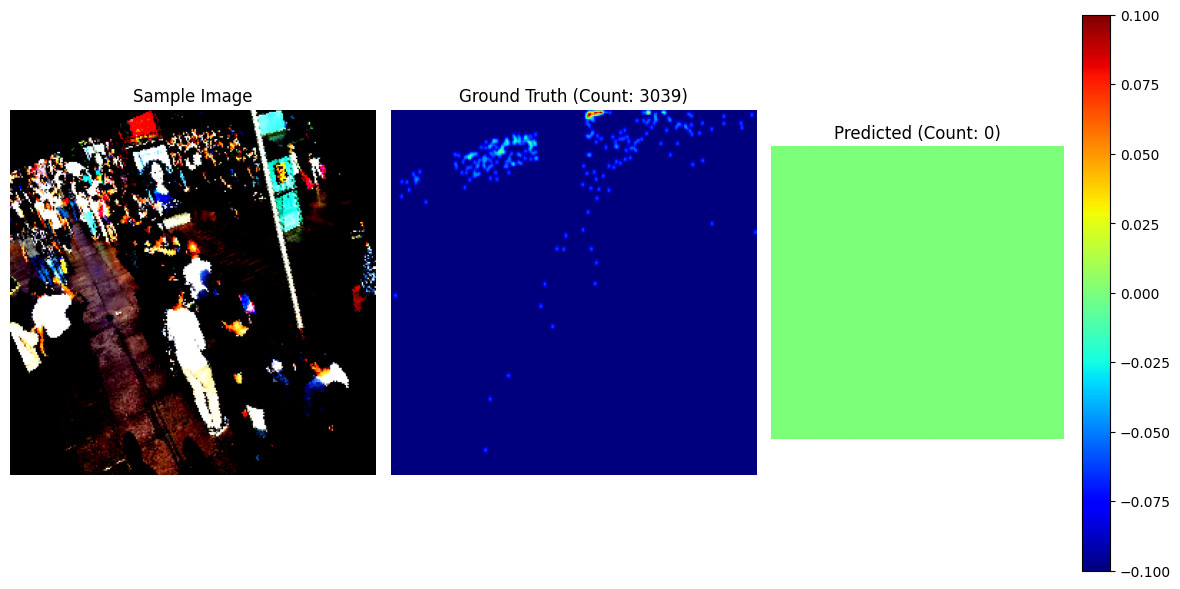

Epoch 8/20, Train Loss: 0.975182117819786, Validation Loss: 0.9748307987104489


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Predicted Density Map Shape: (4, 1, 256, 256)
Raw prediction values range:  0.0010654608 0.011969645
Counted 764 people in the density map.
Counted 0 people in the density map.


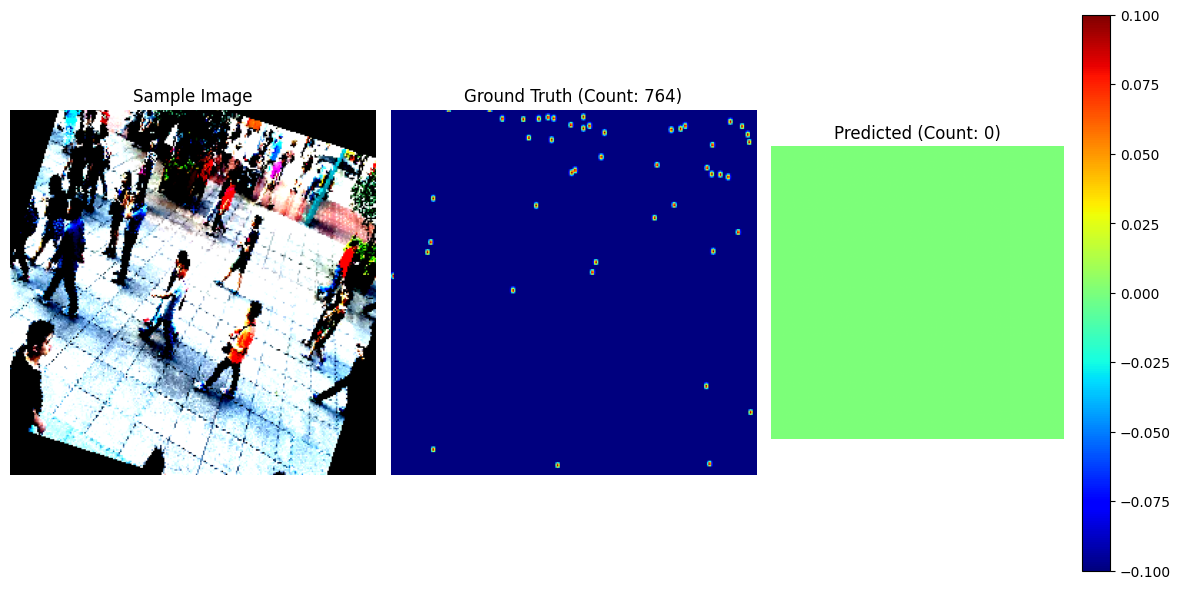

KeyboardInterrupt: 

In [121]:
import matplotlib.pyplot as plt
import numpy as np

early_stopping_patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, gt_maps in train_loader:
        imgs, gt_maps = imgs.to(device), gt_maps.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(imgs)
        outputs = torch.sigmoid(outputs)  # Sigmoid if using BCEWithLogitsLoss
        
        # Compute loss
        loss = criterion(outputs, gt_maps)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    # Validation Loss
    val_loss = evaluate_model(model, val_loader, device)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {running_loss/len(train_loader)}, Validation Loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Early stopping condition
    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping after {epoch+1} epochs due to no improvement.")
        break
    
    # Plot a sample of predicted and ground truth density maps
    model.eval()
    with torch.no_grad():
        sample_img, sample_gt_map = next(iter(val_loader))
        sample_img, sample_gt_map = sample_img.to(device), sample_gt_map.to(device)

        # Forward pass
        pred_density_map = model(sample_img).cpu().numpy()
        
        # Make sure the predictions are non-negative and within the valid range
        pred_density_map = np.maximum(pred_density_map, 0)
        pred_density_map = np.clip(pred_density_map, 0, 1)
        
        print("Predicted Density Map Shape:", pred_density_map.shape)  # Debugging: Check shape

        pred_density_map = pred_density_map[0, 0]  # Access the first image's predicted density map

        # Check the range of the raw prediction
        print("Raw prediction values range: ", np.min(pred_density_map), np.max(pred_density_map))

        # Optional: Skip or adjust thresholding if required
        # Lower threshold to 0.1 (you can adjust or skip thresholding based on the raw output)
        threshold = 0.1
        pred_density_map[pred_density_map < threshold] = 0

        # Count the number of people in both ground truth and predicted density maps
        gt_count = count_people(sample_gt_map.cpu().numpy()[0])  # Ground truth count
        pred_count = count_people(pred_density_map)  # Predicted count

        # Plot the sample image, ground truth density map, and predicted density map
        plt.figure(figsize=(12, 6))
        
        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(sample_img[0].cpu().numpy().transpose(1, 2, 0))  # Convert to HxWxC for imshow
        plt.title("Sample Image")
        plt.axis('off')

        # Ground Truth Density Map
        plt.subplot(1, 3, 2)
        plt.imshow(sample_gt_map[0].cpu().numpy().squeeze(), cmap='jet')  # Squeeze to remove singleton dimension
        plt.title(f"Ground Truth (Count: {gt_count})")
        plt.axis('off')

        # Predicted Density Map (After thresholding)
        plt.subplot(1, 3, 3)
        plt.imshow(pred_density_map, cmap='jet')
        plt.colorbar()
        plt.title(f"Predicted (Count: {pred_count})")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
